# SynthSeg generative pipeline — step by step, reimplemented in NumPy/SciPy
### v3 — hyperparameters matched to the actual shipped code, not just the paper's table

Earlier versions of this notebook found real discrepancies between three
sources that all *sound* authoritative but disagree with each other:

| source | what it actually is |
|---|---|
| The **paper** (Table S1) | hyperparameters used for one specific set of published experiments |
| The **tutorial's comments** | partially stale — e.g. it says the GMM mean prior defaults to `[0, 250]`, which doesn't match the code it sits next to |
| **`BrainGenerator.__init__`'s actual defaults** | what you get any time you run the tool without overriding arguments — the only source that can't drift out of sync with itself |

This version uses the **third one** throughout, since that's what "running SynthSeg" actually produces. All seven of the intensity/geometry hyperparameters below are exposed as ordinary keyword arguments in each step's function — tune them freely per experiment. Where the actual code default differs from the paper, it's called out explicitly in that step's markdown cell.

Two other decisions worth knowing about before you run this:
- **Translation is physically commented out** of the affine step, matching `BrainGenerator`'s own default (`translation_bounds=False`) — the code is left in place with clear instructions to re-enable it.
- **Resolution simulation follows the code**, which does more than the paper's Eq. 20-26 documents: it randomly mixes an *isotropic* low-res mode with the *anisotropic single-axis* mode the paper describes.


## 0. Configuration — repo sample data, or your own label map

Same as before: set `LABEL_MAP_SOURCE`. Using your own label map auto-derives
`generation_labels`/`generation_classes`/`output_labels` with safe defaults if
you don't supply your own `.npy` files, and auto-disables L/R flipping unless
you explicitly provide `OWN_N_NEUTRAL_LABELS` (flipping needs your label
values ordered `[neutral..., left..., right...]`, which can't be safely
inferred for an arbitrary label map).

In [ ]:
# ============================== CONFIGURATION ==============================
LABEL_MAP_SOURCE = 'repo_sample'   # 'repo_sample'  or  'own_file'

# --- only read when LABEL_MAP_SOURCE == 'own_file' ---
OWN_LABEL_MAP_PATH          = '/content/my_label_map.nii.gz'  # upload to Colab (or mount Drive) first
OWN_GENERATION_LABELS_PATH  = None   # optional .npy (1D array of label values); auto-derived if None
OWN_GENERATION_CLASSES_PATH = None   # optional .npy (same length, int class ids); defaults to 1-to-1 if None
OWN_OUTPUT_LABELS_PATH      = None   # optional .npy (same length as generation_labels); defaults to identity if None
OWN_N_NEUTRAL_LABELS        = None   # int; required only if you want L/R flipping enabled (see note above)
# =============================================================================

In [ ]:
!pip install -q nibabel scipy matplotlib numpy

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform, gaussian_filter1d, map_coordinates, zoom

rng = np.random.default_rng()  # re-run any step's cell to resample its randomness


def load_repo_sample():
    os.makedirs('data', exist_ok=True)
    base = 'https://github.com/BBillot/SynthSeg/raw/refs/heads/master'
    files = {
        'data/training_seg_01.nii.gz': f'{base}/data/training_label_maps/training_seg_01.nii.gz',
        'data/generation_labels.npy': f'{base}/data/labels_classes_priors/generation_labels.npy',
        'data/generation_classes.npy': f'{base}/data/labels_classes_priors/generation_classes.npy',
        'data/synthseg_segmentation_labels.npy': f'{base}/data/labels_classes_priors/synthseg_segmentation_labels.npy',
    }
    for path, url in files.items():
        if not os.path.exists(path):
            os.system(f'curl -sL "{url}" -o "{path}"')
    label_map = nib.load('data/training_seg_01.nii.gz').get_fdata().astype(np.int32)
    generation_labels = np.load('data/generation_labels.npy')
    generation_classes = np.load('data/generation_classes.npy')
    output_labels = np.load('data/synthseg_segmentation_labels.npy')
    n_neutral_labels = 18
    flip_enabled = True
    return label_map, generation_labels, generation_classes, output_labels, n_neutral_labels, flip_enabled


def load_own_file():
    label_map = nib.load(OWN_LABEL_MAP_PATH).get_fdata().astype(np.int32)

    if OWN_GENERATION_LABELS_PATH:
        generation_labels = np.load(OWN_GENERATION_LABELS_PATH)
    else:
        generation_labels = np.unique(label_map)
        print(f'[auto] generation_labels derived from your volume: {len(generation_labels)} unique values')

    if OWN_GENERATION_CLASSES_PATH:
        generation_classes = np.load(OWN_GENERATION_CLASSES_PATH)
    else:
        generation_classes = np.arange(len(generation_labels))
        print('[auto] generation_classes defaulted to 1-to-1 (every label is its own class)')

    if OWN_OUTPUT_LABELS_PATH:
        output_labels = np.load(OWN_OUTPUT_LABELS_PATH)
    else:
        output_labels = generation_labels.copy()
        print('[auto] output_labels defaulted to identity (target keeps every label)')

    if OWN_N_NEUTRAL_LABELS is not None:
        n_neutral_labels = OWN_N_NEUTRAL_LABELS
        flip_enabled = True
    else:
        n_neutral_labels = None
        flip_enabled = False
        print('[auto] OWN_N_NEUTRAL_LABELS not set -> L/R flip step will be SKIPPED for this run')

    return label_map, generation_labels, generation_classes, output_labels, n_neutral_labels, flip_enabled


if LABEL_MAP_SOURCE == 'repo_sample':
    label_map, generation_labels, generation_classes, output_labels, n_neutral_labels, FLIP_ENABLED = load_repo_sample()
elif LABEL_MAP_SOURCE == 'own_file':
    label_map, generation_labels, generation_classes, output_labels, n_neutral_labels, FLIP_ENABLED = load_own_file()
else:
    raise ValueError("LABEL_MAP_SOURCE must be 'repo_sample' or 'own_file'")

print('label map shape:', label_map.shape)
print('number of distinct labels:', len(np.unique(label_map)))
print('flip step enabled:', FLIP_ENABLED)

label map shape: (256, 256, 256)
number of distinct labels: 54
flip step enabled: True


## Visualization helpers

In [ ]:
def mid_slices(volume):
    x, y, z = np.array(volume.shape) // 2
    return volume[x, :, :], volume[:, y, :], volume[:, :, z]


def format_params(params):
    if not params:
        return ""
    parts = []
    for k, v in params.items():
        if isinstance(v, float):
            parts.append(f"{k}={v:.3g}")
        elif isinstance(v, (list, tuple)) and len(v) <= 3 and all(isinstance(x, (int, float)) for x in v):
            parts.append(f"{k}=[{', '.join(f'{x:.2f}' if isinstance(x, float) else str(x) for x in v)}]")
        else:
            parts.append(f"{k}={v}")
    return "\n".join(parts)


def plot_stage(title, volume, is_label, params=None, figsize=(9, 3)):
    cmap = 'nipy_spectral' if is_label else 'gray'
    slices = mid_slices(volume)
    view_names = ['Sagittal', 'Coronal', 'Axial']
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for col, ax in enumerate(axes):
        ax.imshow(np.rot90(slices[col]), cmap=cmap)
        ax.set_title(view_names[col], fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=13, y=1.05)
    param_str = format_params(params)
    if param_str:
        fig.text(1.0, 0.5, param_str, transform=axes[2].transAxes, fontsize=8,
                  va='center', ha='left', family='monospace')
    plt.tight_layout()
    plt.show()


def plot_pipeline(stages, save_path=None):
    n = len(stages)
    fig, axes = plt.subplots(n, 3, figsize=(9, 2.6 * n))
    view_names = ['Sagittal', 'Coronal', 'Axial']
    for row, stage in enumerate(stages):
        vol = stage['volume']
        cmap = 'nipy_spectral' if stage.get('is_label', False) else 'gray'
        slices = mid_slices(vol)
        for col in range(3):
            ax = axes[row, col]
            ax.imshow(np.rot90(slices[col]), cmap=cmap)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(view_names[col], fontsize=11)
        axes[row, 0].set_ylabel(stage['title'], fontsize=10, rotation=0,
                                 ha='right', va='center', labelpad=10)
        param_str = format_params(stage.get('params', {}))
        if param_str:
            axes[row, 2].text(1.05, 0.5, param_str, transform=axes[row, 2].transAxes,
                               fontsize=7, va='center', ha='left', family='monospace')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

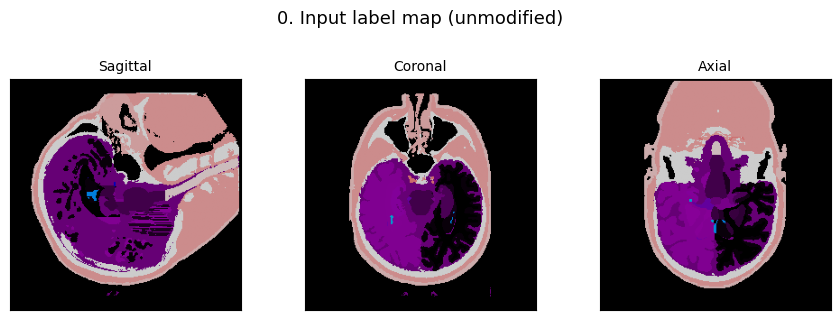

In [ ]:
plot_stage('0. Input label map (unmodified)', label_map, is_label=True)

## Step 1 — Random L/R flip

Unchanged from v2: mirrors the volume and swaps left/right label *values*.

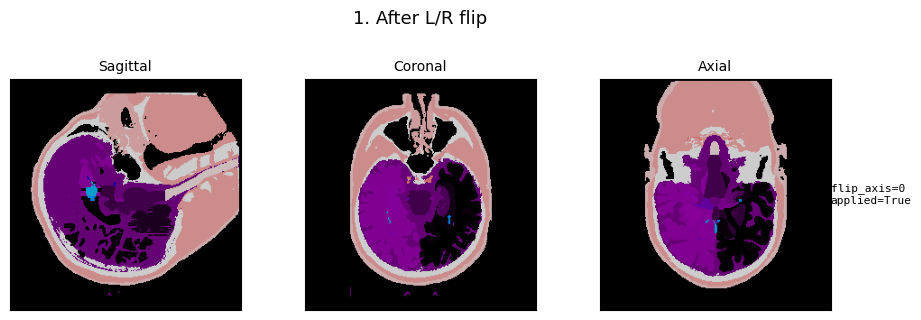

In [ ]:
def flip_lr(label_map, generation_labels, n_neutral_labels, flip_axis=0, p=1.0):
    params = {'flip_axis': flip_axis, 'applied': False}
    if rng.random() >= p:
        return label_map.copy(), params
    params['applied'] = True
    n_sided = (len(generation_labels) - n_neutral_labels) // 2
    left_labels = generation_labels[n_neutral_labels:n_neutral_labels + n_sided]
    right_labels = generation_labels[n_neutral_labels + n_sided:]
    swap_map = {int(l): int(r) for l, r in zip(left_labels, right_labels)}
    swap_map.update({int(r): int(l) for l, r in zip(left_labels, right_labels)})
    flipped = np.flip(label_map, axis=flip_axis).copy()
    out = flipped.copy()
    for src, dst in swap_map.items():
        out[flipped == src] = dst
    return out, params

# --- run this step ---
if FLIP_ENABLED:
    flipped, p1 = flip_lr(label_map, generation_labels, n_neutral_labels, flip_axis=0, p=1.0)
else:
    flipped, p1 = label_map.copy(), {'applied': False, 'reason': 'flip disabled for this data source'}
plot_stage('1. After L/R flip', flipped, is_label=True, params=p1)

## Step 2 — Random affine deformation

Defaults now match `BrainGenerator`'s actual class defaults:
`rotation_bounds=15` (not the paper's 20), `scaling_bounds=0.2` (unchanged,
gives `[0.8, 1.2]`), `shearing_bounds=0.012` (not the paper's 0.015) —
**tunable**, change these freely per experiment.

**Translation is physically commented out below**, matching `BrainGenerator`'s
own default (`translation_bounds=False` — off unless you explicitly turn it
on). To re-enable it: uncomment the marked line inside the function, and
call `affine_deform(flipped, translation_bounds=30)` (30mm matches the
paper's Table S1, if you want that specific value back).

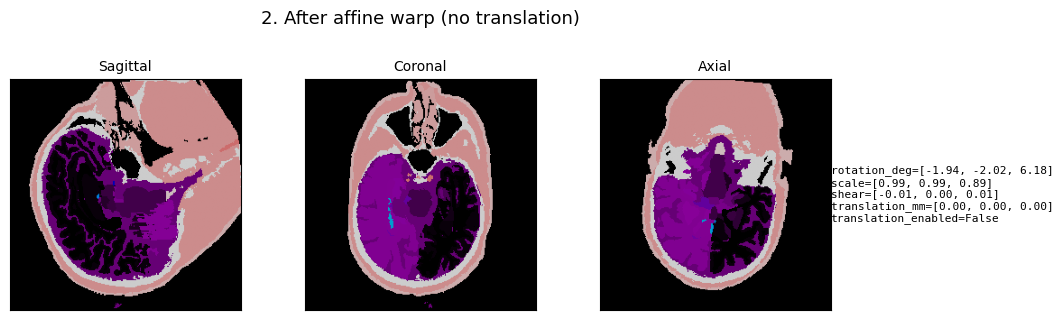

In [ ]:
def affine_deform(label_map, rotation_bounds=15.0, scaling_bounds=0.2, shearing_bounds=0.012,
                   translation_bounds=False):
    angles_deg = rng.uniform(-rotation_bounds, rotation_bounds, size=3)
    scale = rng.uniform(1 - scaling_bounds, 1 + scaling_bounds, size=3)
    shear = rng.uniform(-shearing_bounds, shearing_bounds, size=3)

    # ---- TRANSLATION (off by default, matching BrainGenerator's translation_bounds=False) ----
    # To enable: uncomment the line below, and pass e.g. translation_bounds=30 when calling this function.
    # translation = rng.uniform(-translation_bounds, translation_bounds, size=3)
    translation = np.zeros(3)
    # -----------------------------------------------------------------------------------------

    ax, ay, az = np.deg2rad(angles_deg)
    Rx = np.array([[1, 0, 0], [0, np.cos(ax), -np.sin(ax)], [0, np.sin(ax), np.cos(ax)]])
    Ry = np.array([[np.cos(ay), 0, np.sin(ay)], [0, 1, 0], [-np.sin(ay), 0, np.cos(ay)]])
    Rz = np.array([[np.cos(az), -np.sin(az), 0], [np.sin(az), np.cos(az), 0], [0, 0, 1]])
    R = Rz @ Ry @ Rx
    S = np.diag(scale)
    Sh = np.array([[1, shear[0], shear[1]], [shear[0], 1, shear[2]], [shear[1], shear[2], 1]])
    A = R @ S @ Sh

    center = np.array(label_map.shape) / 2.0
    offset = center - A @ center - translation
    warped = affine_transform(label_map, A, offset=offset, order=0, mode='constant', cval=0)
    params = {'rotation_deg': angles_deg.tolist(), 'scale': scale.tolist(), 'shear': shear.tolist(),
              'translation_mm': translation.tolist(), 'translation_enabled': bool(translation_bounds)}
    return warped, params

# --- run this step ---
affined, p2 = affine_deform(flipped)
plot_stage('2. After affine warp (no translation)', affined, is_label=True, params=p2)

## Step 3 — Random diffeomorphic (nonlinear) deformation

Same scaling-and-squaring integration as v2 (Arsigny et al. 2006 method).
**One fix from v2**: the control grid size is now computed as a *ratio* of
the volume shape (`nonlin_scale=0.04`), matching how the real code
parameterizes it — for a 256³ volume this gives ~10³, consistent with the
paper's stated grid, but it now scales correctly if you use a
different-sized label map. `nonlin_std=4.0` matches both the paper and code.

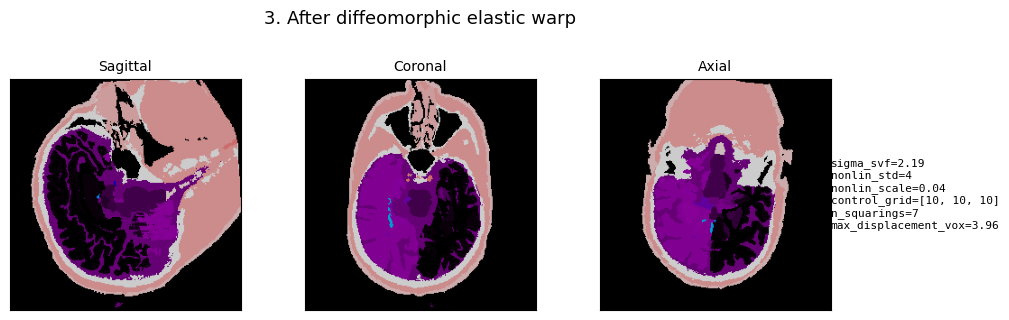

In [ ]:
def elastic_deform(label_map, nonlin_std=4.0, nonlin_scale=0.04, n_squarings=7):
    shape = label_map.shape
    control_grid = tuple(max(2, round(s * nonlin_scale)) for s in shape)

    sigma_svf = rng.uniform(0, nonlin_std)
    svf_small = rng.normal(0, sigma_svf, size=(3,) + control_grid).astype(np.float32)

    disp = svf_small / (2 ** n_squarings)
    xx, yy, zz = np.meshgrid(np.arange(control_grid[0], dtype=np.float32),
                              np.arange(control_grid[1], dtype=np.float32),
                              np.arange(control_grid[2], dtype=np.float32), indexing='ij')
    identity = np.stack([xx, yy, zz], axis=0)
    for _ in range(n_squarings):
        coords = identity + disp
        warped_disp = np.stack([map_coordinates(disp[i], coords, order=1, mode='nearest') for i in range(3)], axis=0)
        disp = warped_disp + disp

    zoom_factors = [s / g for s, g in zip(shape, control_grid)]
    disp_full = np.stack([zoom(disp[i], zoom_factors, order=1).astype(np.float32) for i in range(3)], axis=0)

    xxf, yyf, zzf = np.meshgrid(np.arange(shape[0], dtype=np.float32),
                                 np.arange(shape[1], dtype=np.float32),
                                 np.arange(shape[2], dtype=np.float32), indexing='ij')
    coords_full = np.stack([xxf + disp_full[0], yyf + disp_full[1], zzf + disp_full[2]], axis=0)
    warped = map_coordinates(label_map, coords_full, order=0, mode='constant', cval=0)
    params = {'sigma_svf': float(sigma_svf), 'nonlin_std': nonlin_std, 'nonlin_scale': nonlin_scale,
              'control_grid': control_grid, 'n_squarings': n_squarings,
              'max_displacement_vox': float(np.abs(disp_full).max())}
    return warped, params

# --- run this step (~10-20s on Colab CPU) ---
elastic, p3 = elastic_deform(affined)
plot_stage('3. After diffeomorphic elastic warp', elastic, is_label=True, params=p3)

## Step 4 — GMM intensity sampling: **label map → synthetic image**

**Corrected defaults**: $\mu \sim \mathcal{U}(25, 225)$,
$\sigma \sim \mathcal{U}(5, 25)$ — matching `BrainGenerator`'s actual
`prior_means`/`prior_stds` defaults, not the paper's wider
$\mathcal{U}(0,255)$/$\mathcal{U}(0,35)$. This is a meaningfully tighter
prior and is a large part of why v2's output looked more extreme than
what SynthSeg actually ships with. **Tunable** — both ranges are ordinary
keyword arguments.

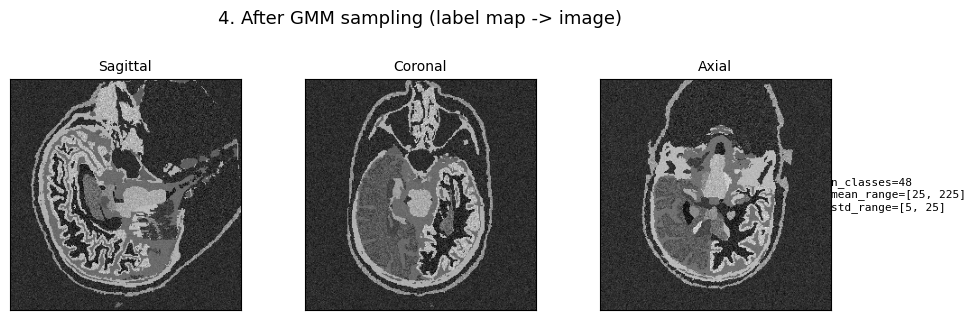

In [ ]:
def sample_gmm_image(label_map, generation_labels, generation_classes,
                      mean_range=(25, 225), std_range=(5, 25)):
    n_classes = int(generation_classes.max()) + 1
    class_means = rng.uniform(mean_range[0], mean_range[1], size=n_classes)
    class_stds = rng.uniform(std_range[0], std_range[1], size=n_classes)

    max_label = int(generation_labels.max())
    label_to_class_lut = np.full(max_label + 1, -1, dtype=np.int32)
    label_to_class_lut[generation_labels.astype(np.int32)] = generation_classes.astype(np.int32)

    safe_labels = np.clip(label_map, 0, max_label)
    class_of_voxel = label_to_class_lut[safe_labels]
    valid = class_of_voxel >= 0

    eps = rng.normal(0, 1, size=label_map.shape).astype(np.float32)
    mu_field = np.where(valid, class_means[np.clip(class_of_voxel, 0, None)], 0.0)
    sigma_field = np.where(valid, class_stds[np.clip(class_of_voxel, 0, None)], 0.0)
    image = (mu_field + sigma_field * eps).astype(np.float32)
    image = np.clip(np.where(valid, image, 0.0), 0, None)

    params = {'n_classes': n_classes, 'mean_range': mean_range, 'std_range': std_range}
    return image, params

# --- run this step ---
image, p4 = sample_gmm_image(elastic, generation_labels, generation_classes)
plot_stage('4. After GMM sampling (label map -> image)', image, is_label=False, params=p4)

## Step 5 — Bias field corruption

**Fixed from v2**: `bias_field_std=0.7` (the code/tutorial value — Table S1's
0.6 was for a specific experiment configuration, not the shipped default).
Grid size is now `bias_scale=0.025` × volume shape (for 256³: ~6³), matching
how the code actually parameterizes it, instead of v2's fixed absolute 4³.
**Tunable.**

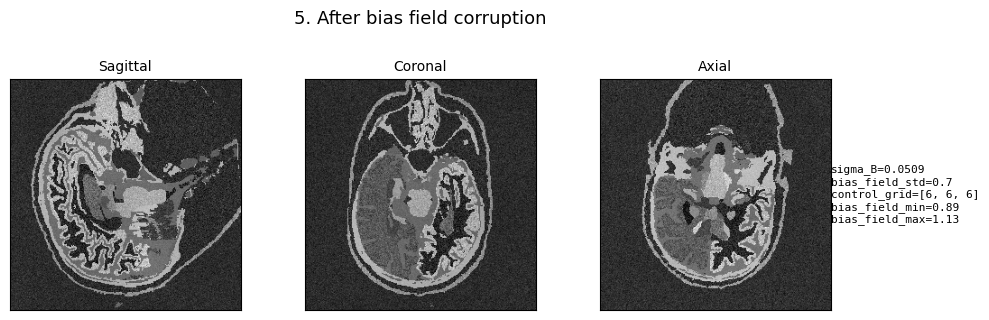

In [ ]:
def add_bias_field(image, bias_field_std=0.7, bias_scale=0.025):
    shape = image.shape
    control_grid = tuple(max(2, round(s * bias_scale)) for s in shape)
    sigma_B = rng.uniform(0, bias_field_std)
    coarse = rng.normal(0, sigma_B, size=control_grid)
    zoom_factors = [s / g for s, g in zip(shape, control_grid)]
    B = zoom(coarse, zoom_factors, order=1)
    bias_field = np.exp(B)
    corrupted = image * bias_field
    params = {'sigma_B': float(sigma_B), 'bias_field_std': bias_field_std, 'control_grid': control_grid,
              'bias_field_min': float(bias_field.min()), 'bias_field_max': float(bias_field.max())}
    return corrupted, bias_field, params

# --- run this step ---
biased, bias_field, p5 = add_bias_field(image)
plot_stage('5. After bias field corruption', biased, is_label=False, params=p5)

## Step 6 — Clip + normalize + random Gamma transform

**Two fixes from v2**: `gamma_std=0.5` (the actual hardcoded value inside
`labels_to_image_model.py`'s `IntensityAugmentation` layer — the paper's
$\sqrt{0.4}\approx0.63$ is close but not identical, and is what made v2 look
more contrasty than real SynthSeg output). Also added the **`clip=300`** step
that happens right before normalization in the real code, capping
bias-field-amplified outliers. **`gamma_std` is tunable** — turn it down for
subtler contrast variation, or up for more.

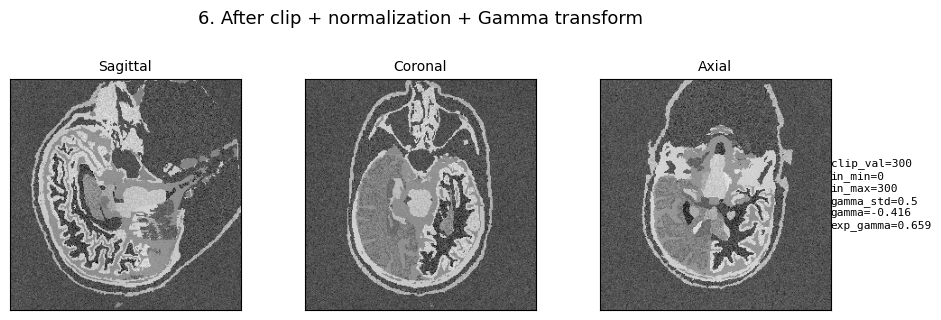

In [ ]:
def normalize_and_gamma(image, gamma_std=0.5, clip_val=300.0):
    clipped = np.clip(image, 0, clip_val)
    lo, hi = clipped.min(), clipped.max()
    normed = (clipped - lo) / (hi - lo + 1e-8)
    gamma = rng.normal(0, gamma_std)
    out = np.power(np.clip(normed, 0, 1), np.exp(gamma))
    params = {'clip_val': clip_val, 'in_min': float(lo), 'in_max': float(hi),
              'gamma_std': gamma_std, 'gamma': float(gamma), 'exp_gamma': float(np.exp(gamma))}
    return out, params

# --- run this step ---
gammaed, p6 = normalize_and_gamma(biased)
plot_stage('6. After clip + normalization + Gamma transform', gammaed, is_label=False, params=p6)

## Step 7 — Simulated resolution

**Richer than v2**: the actual code exposes *both* `max_res_iso=4.0`
(isotropic low-res — blur/downsample/upsample all 3 axes) and
`max_res_aniso=8.0` (single-axis thick-slice, what v2 always did), and picks
between them per sample. The exact mixing rule isn't published in the paper
or the docstring, so **this notebook uses a documented 50/50 coin flip** —
flagged here as an assumption, not a verified detail. Force a specific mode
with `simulate_resolution(gammaed, mode='iso')` or `mode='aniso'`.

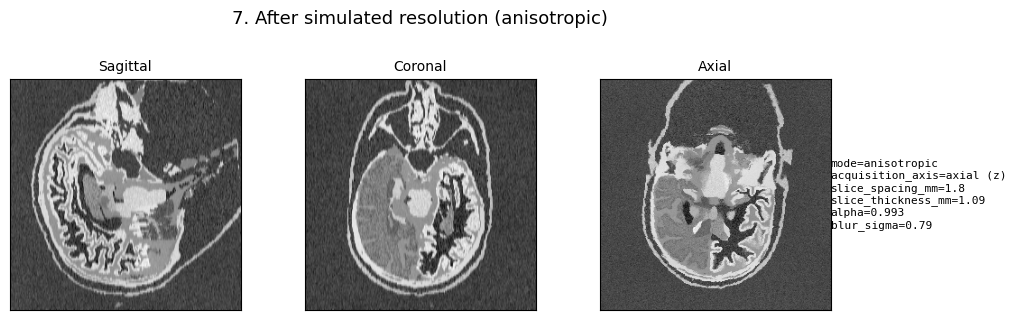

In [ ]:
def simulate_resolution(image, r_hr=1.0, max_res_iso=4.0, max_res_aniso=8.0,
                         a_alpha=0.95, b_alpha=1.05, mode=None, axis=None):
    mode = mode if mode is not None else ('iso' if rng.random() < 0.5 else 'aniso')

    if mode == 'iso':
        r_spac = rng.uniform(r_hr, max_res_iso)
        alpha = rng.uniform(a_alpha, b_alpha)
        sigma_thick = 2 * alpha * np.log(10) / (2 * np.pi) * (r_spac / r_hr)
        blurred = image
        for ax_ in range(3):
            blurred = gaussian_filter1d(blurred, sigma=sigma_thick, axis=ax_)
        factor = r_hr / r_spac
        downsampled = zoom(blurred, [factor, factor, factor], order=1)
        upsampled = zoom(downsampled, np.array(image.shape) / np.array(downsampled.shape), order=1)
        out = np.zeros_like(image)
        sl = tuple(slice(0, min(s, t)) for s, t in zip(upsampled.shape, image.shape))
        out[sl] = upsampled[sl]
        params = {'mode': 'isotropic', 'resolution_mm': float(r_spac), 'alpha': float(alpha),
                  'blur_sigma': float(sigma_thick)}
        return out, params

    else:
        axis = axis if axis is not None else int(rng.integers(0, 3))
        r_spac = rng.uniform(r_hr, max_res_aniso)
        r_thick = rng.uniform(r_hr, r_spac)
        alpha = rng.uniform(a_alpha, b_alpha)
        sigma_thick = 2 * alpha * np.log(10) / (2 * np.pi) * (r_thick / r_hr)
        blurred = gaussian_filter1d(image, sigma=sigma_thick, axis=axis)
        zoom_factors = [1.0, 1.0, 1.0]; zoom_factors[axis] = r_hr / r_spac
        downsampled = zoom(blurred, zoom_factors, order=1)
        up_factors = [1.0, 1.0, 1.0]; up_factors[axis] = image.shape[axis] / downsampled.shape[axis]
        upsampled = zoom(downsampled, up_factors, order=1)
        out = np.zeros_like(image)
        sl = tuple(slice(0, min(s, t)) for s, t in zip(upsampled.shape, image.shape))
        out[sl] = upsampled[sl]
        axis_name = ['sagittal (x)', 'coronal (y)', 'axial (z)'][axis]
        params = {'mode': 'anisotropic', 'acquisition_axis': axis_name, 'slice_spacing_mm': float(r_spac),
                  'slice_thickness_mm': float(r_thick), 'alpha': float(alpha), 'blur_sigma': float(sigma_thick)}
        return out, params

# --- run this step ---
lowres, p7 = simulate_resolution(gammaed)
plot_stage(f"7. After simulated resolution ({p7['mode']})", lowres, is_label=False, params=p7)

## Step 8 — Remap to the segmentation target `T`

Unchanged from v2.

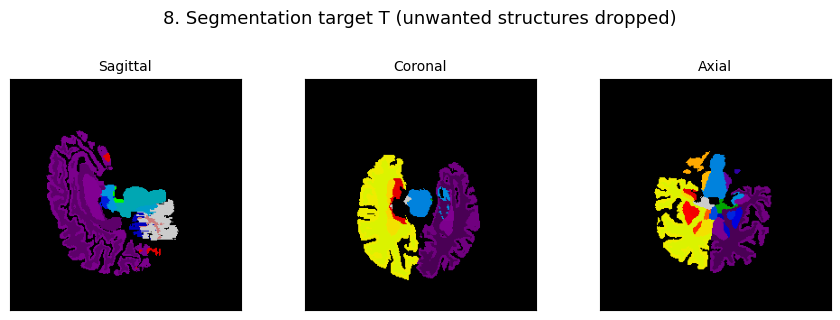

In [ ]:
def remap_to_output_labels(label_map, generation_labels, output_labels):
    max_label = int(generation_labels.max())
    lut = np.zeros(max_label + 1, dtype=np.int32)
    lut[generation_labels.astype(np.int32)] = output_labels.astype(np.int32)
    safe = np.clip(label_map, 0, max_label)
    return lut[safe]

# --- run this step ---
target = remap_to_output_labels(elastic, generation_labels, output_labels)
plot_stage('8. Segmentation target T (unwanted structures dropped)', target, is_label=True)

## Step 9 — Random crop to training patch size

Unchanged from v2 (still crops to 160³ by default, and correctly reports the
actual applied shape if your volume is smaller than the requested crop).

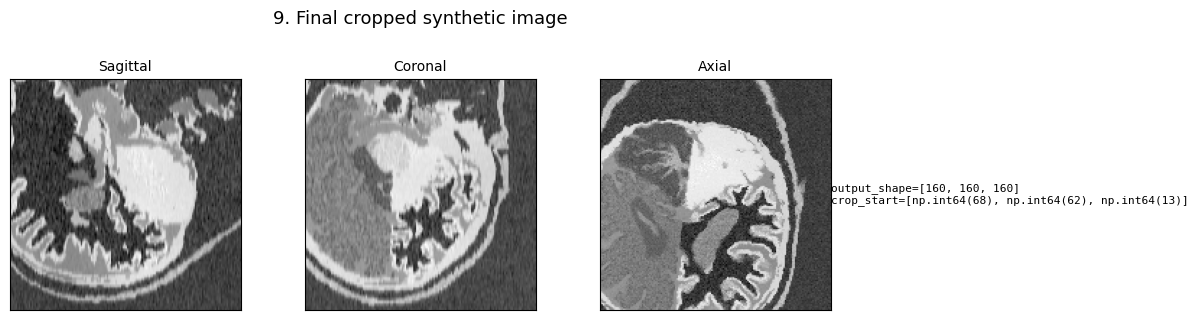

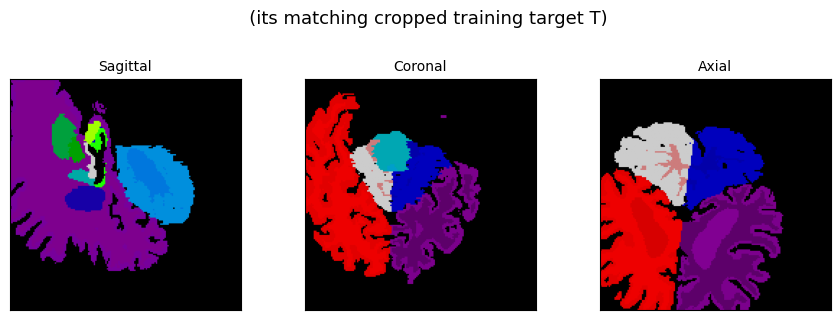

In [ ]:
def random_crop(image, target_label_map, output_shape=160):
    shape = image.shape
    if isinstance(output_shape, int):
        output_shape = (output_shape,) * 3
    actual_shape = [min(o, s) for s, o in zip(shape, output_shape)]
    starts = [0 if s == o else rng.integers(0, s - o) for s, o in zip(shape, actual_shape)]
    slices = tuple(slice(st, st + o) for st, o in zip(starts, actual_shape))
    params = {'output_shape': actual_shape, 'crop_start': starts}
    return image[slices], target_label_map[slices], params

# --- run this step ---
cropped_img, cropped_target, p9 = random_crop(lowres, target, output_shape=160)
plot_stage('9. Final cropped synthetic image', cropped_img, is_label=False, params=p9)
plot_stage('   (its matching cropped training target T)', cropped_target, is_label=True)

## Combined view — the full pipeline at a glance

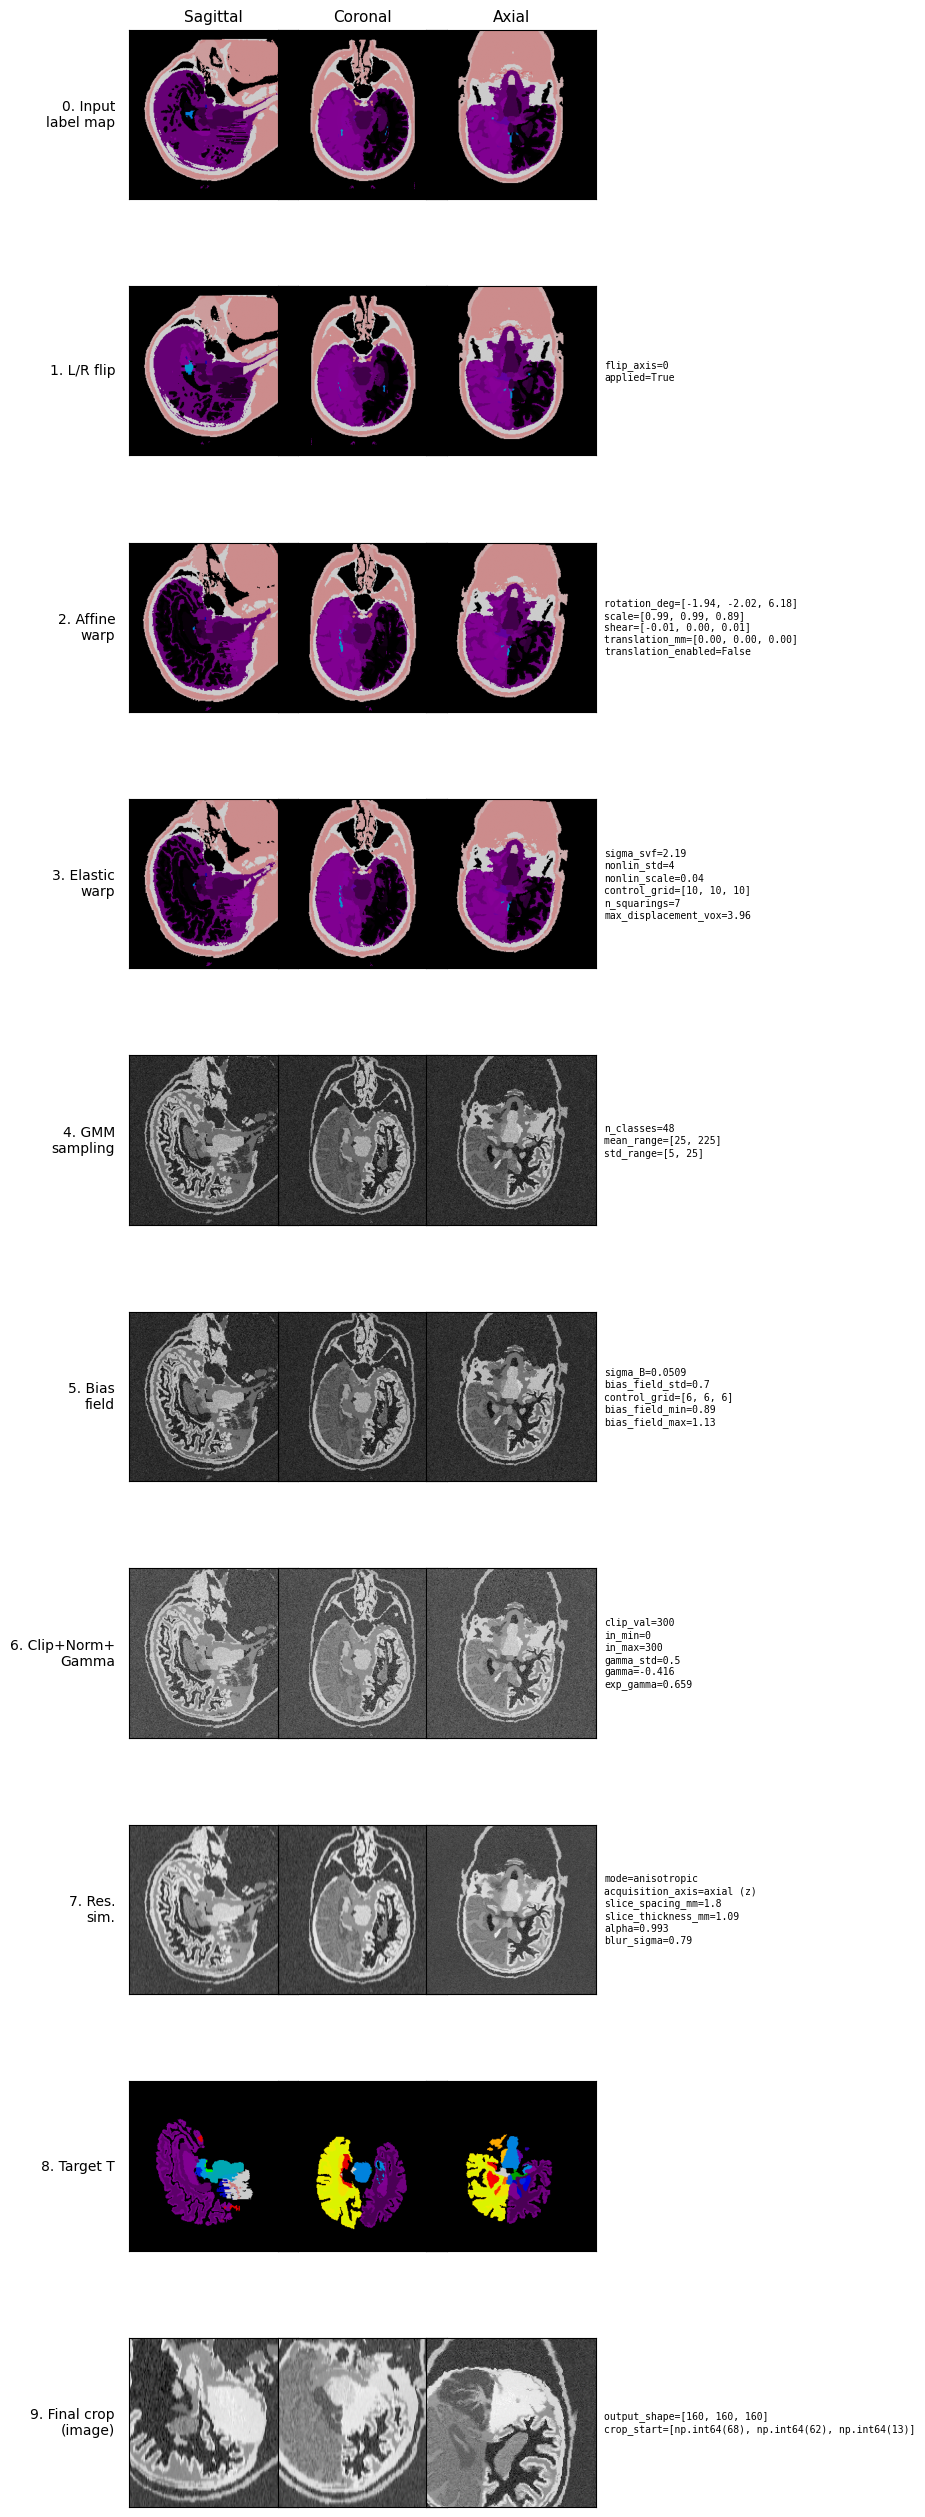

In [ ]:
stages = [
    {'title': '0. Input\nlabel map', 'volume': label_map, 'is_label': True, 'params': {}},
    {'title': '1. L/R flip', 'volume': flipped, 'is_label': True, 'params': p1},
    {'title': '2. Affine\nwarp', 'volume': affined, 'is_label': True, 'params': p2},
    {'title': '3. Elastic\nwarp', 'volume': elastic, 'is_label': True, 'params': p3},
    {'title': '4. GMM\nsampling', 'volume': image, 'is_label': False, 'params': p4},
    {'title': '5. Bias\nfield', 'volume': biased, 'is_label': False, 'params': p5},
    {'title': '6. Clip+Norm+\nGamma', 'volume': gammaed, 'is_label': False, 'params': p6},
    {'title': '7. Res.\nsim.', 'volume': lowres, 'is_label': False, 'params': p7},
    {'title': '8. Target T', 'volume': target, 'is_label': True, 'params': {}},
    {'title': '9. Final crop\n(image)', 'volume': cropped_img, 'is_label': False, 'params': p9},
]

plot_pipeline(stages, save_path='synthseg_pipeline_strip.png')

## Known simplifications — read this before treating any output as ground truth

1. **Affine and elastic warps are two separate resampling passes**, so each
   can be visualized on its own. The paper composes them into a single
   nearest-neighbour resampling (Eq. 10) to avoid stacking interpolation
   error.
2. **The elastic field is integrated at its native small grid, then upsampled
   once**, not upsampled-then-integrated at full resolution as Eq. 8-9
   literally order it. Numerically close for a smooth field; ~10x faster.
3. **Skull-stripping simulation and lesion pasting are not implemented**
   (Section 4.2, Supplements 3-4) — they need extra label lists not part of
   the base tutorial data.
4. **L/R flip probability** isn't given as an equation anywhere — exposed as
   a `p` argument, default: always applied.
5. **Translation is off by default**, matching `BrainGenerator`, but is
   physically commented out (not just defaulted) in Step 2's code — uncomment
   to re-enable.
6. **The iso/aniso resolution mixing rule is an assumption** (documented
   50/50 coin flip) — the actual mixing logic isn't published anywhere we
   could find; only the fact that both modes exist is confirmed from the
   code's parameter list.
7. **Hyperparameter source**: all seven tunable values (GMM mean/std priors,
   shearing bounds, bias field std, gamma std, and the res-sim bounds) use
   `BrainGenerator`'s actual class defaults, confirmed by reading
   `SynthSeg/brain_generator.py` and `SynthSeg/labels_to_image_model.py`
   directly — not the paper's Table S1, which describes one specific
   published experiment configuration rather than the tool's shipped
   defaults.

## Play with the parameters

All seven tunable hyperparameters, with their code-accurate defaults:

| step | parameter | default | paper's value (if different) |
|---|---|---|---|
| 2 | `shearing_bounds` | 0.012 | 0.015 |
| 2 | `translation_bounds` | off (commented out) | ±30mm |
| 4 | `mean_range` | (25, 225) | (0, 255) |
| 4 | `std_range` | (5, 25) | (0, 35) |
| 5 | `bias_field_std` | 0.7 | 0.6 |
| 6 | `gamma_std` | 0.5 | ~0.63 |
| 7 | `max_res_iso` / `max_res_aniso` | 4.0 / 8.0 | (aniso only) 9.0 |

Change any of these in its step's cell and re-run everything after it to
propagate the change through to the combined strip. A few things worth
trying:
- `gamma_std=0.05` for barely-there contrast skew vs `gamma_std=1.2` for extreme
- `mean_range=(50, 200)` for a narrower, more T1-like contrast band
- Uncomment translation in Step 2, call with `translation_bounds=30`, for
  framing variation
- Force `simulate_resolution(gammaed, mode='iso')` vs `mode='aniso'` to see
  the difference directly

Since each stage is a plain array, you can also splice the pipeline — e.g.
skip Step 3 and feed `affined` straight into Step 4.